# Financials

We now take together all the individual steps we have taken to calculate the Expected damage distribution for a certain portfolio to find its fair price. 

In [1]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.append('../src')

from utils.track import track_interpolation, cyclone_velocity, cyclone_bearing


To do so we first generate a ensemble of 1000 syntethic years with cyclone tracks. We then combine each of those individual tracks to calculate a loss for individual storms yielding a total loss per yer. Note that we here expect for simplicity that the same portfolio can be hit twice by a storm in a year. 


In [3]:
from probabilistic import SyntheticTCCatalog

model = SyntheticTCCatalog(basin='al', grid_size=2.0, max_hours=360, verbose=False)
model.fit("/Users/wirths/Documents/Private/NatCat/data/raw")


SyntheticTCCatalog(basin='al', grid_size=2.0, max_hours=360, time_step=3.0, status=fitted)

In [4]:
from hazards.tropical_cyclone import TropicalCycloneHazard
from vulnerability import WindVulnerability
from loss_model import LossCalculator


#Set portfolio: 
from preprocessing.tropical_cyclone import get_country_exposure_via_api, convert_to_loss_model_format
portfolio = get_country_exposure_via_api("USA", [24.5, 32.0, -87.6, -80.0])
portfolio = convert_to_loss_model_format(portfolio)

# Set buffer around portfolio 
buf = 5.0 
lat_min, lat_max = 24.5 - buf, 32.0 + buf
lon_min, lon_max = -87.6 - buf, -80.0 + buf

# Dataflow across a year: 
num_years = 10

# vulnerbility 
vulnerability = WindVulnerability()

losses_per_year = []
for i in tqdm(range(num_years), desc="Simulating years"):
    synthetic_tracks = model.generate(n_years=1)

    #Get amount of stroms per year
    num_storms = len(synthetic_tracks['storm_id'].unique())
    
    #Now we isolate a syntehtic storm 
    losses_this_year = []
    for storm_id in synthetic_tracks['storm_id'].unique():
        storm_data = synthetic_tracks[synthetic_tracks['storm_id'] == storm_id].copy()

        # Skip storms outside of buffer zone 
        near_portfolio = (
            storm_data['latitude'].between(lat_min, lat_max) &
            storm_data['longitude'].between(lon_min, lon_max)
        ).any()
        if not near_portfolio:
            continue

        # add timestamp for compatability 
        storm_data['timestamp'] = pd.Timestamp('1900-01-01') + pd.to_timedelta(storm_data['hour'] * model.time_step, unit='h')

        # interpolate track for precisssion. Warning!!! This can blow up the compuatation time by alot 
        storm_data = track_interpolation(storm_data, time_step='1h')
        storm_data = cyclone_velocity(storm_data)
        storm_data = cyclone_bearing(storm_data)

        hazard = TropicalCycloneHazard(storm_data)
        loss = LossCalculator(hazard, vulnerability)
        loss.calculate_portfolio_loss(portfolio)
        losses_this_year.append(loss.total_loss)
    losses_per_year.append(sum(losses_this_year))

Initializing CLIMADA Data Client...
Downloading/Loading USA exposure data (this may take a moment)...
Filtering for subregion: [24.5, 32.0, -87.6, -80.0]...


Simulating years: 100%|██████████| 10/10 [00:07<00:00,  1.35it/s]


Form this we can now also calculate the AAL (Average Annual Loss) by taking the aritmetic mean. 

### Refactored: LossSimulator Class

This functionality is condesnsed in the `LossSimulator` class that we can just run directly and that keeps track of all objects inside (storm_tracks etc.) so we can investigate it afterwards.


In [64]:
from simulation import LossSimulator

sim = LossSimulator(model, portfolio, vulnerability, portfolio_bounds=(lat_min, lat_max, lon_min, lon_max), buf=buf)
sim.run(n_years=1000)
print(f"AAL = ${sim.aal*1e-9:,.2f} Billion $")


Simulating years: 100%|██████████| 1000/1000 [20:07<00:00,  1.21s/it]  

AAL = $8.90 Billion $


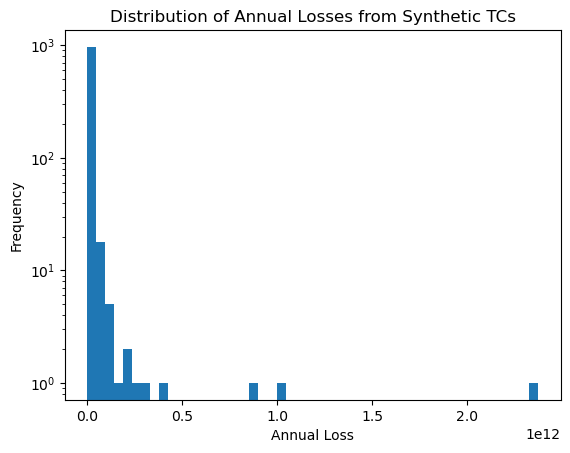

In [72]:
# Make historgam of losses per year
plt.hist(sim.losses_per_year, bins=50)
plt.yscale('log')
plt.xlabel("Annual Loss")
plt.ylabel("Frequency")
plt.title("Distribution of Annual Losses from Synthetic TCs")
plt.show()


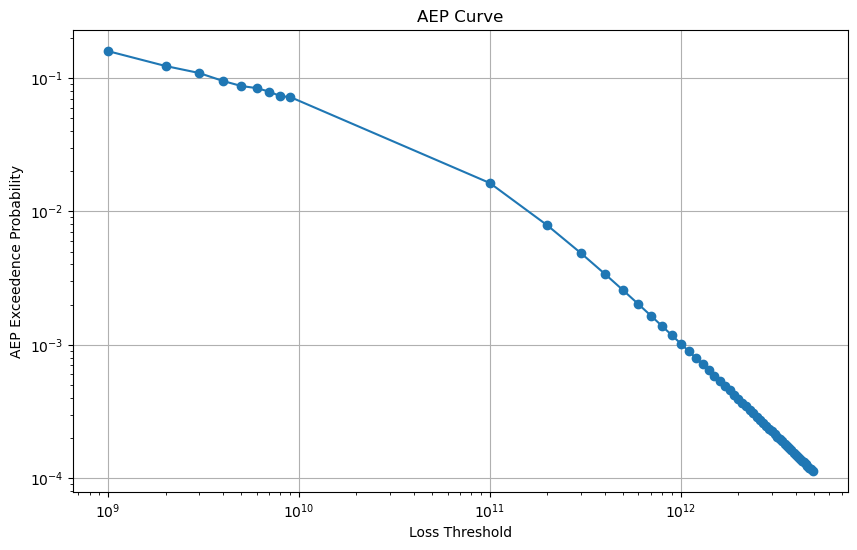

In [87]:
from reinsurance import ExceedenceProbabilityCalculator

ep_calculator = ExceedenceProbabilityCalculator(sim)
ep_calculator.plot_EP_curve(np.concatenate([np.arange(1, 10) * 1e9, np.arange(1, 50) * 1e11]),method="AEP")
